In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import  style
style.use('dark_background')
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler,autocast
from torch.utils.data import DataLoader,TensorDataset
import torchvision
from torchvision import datasets,transforms
from torchsummary import summary

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [18]:
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [19]:
train_data = datasets.ImageFolder(root = 'Deep learning Data/New Plant Diseases Dataset(Augmented)/train',transform = transform_train)
test_data = datasets.ImageFolder(root = 'Deep learning Data/New Plant Diseases Dataset(Augmented)/valid',transform = transform_test)

In [20]:
image,label = train_data[0]
print(image.shape)
len(train_data.classes)

torch.Size([3, 224, 224])


38

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6862745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..0.41960788].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.62352943].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..0.5058824].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8745098..0.28627455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7647059..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.78039217.

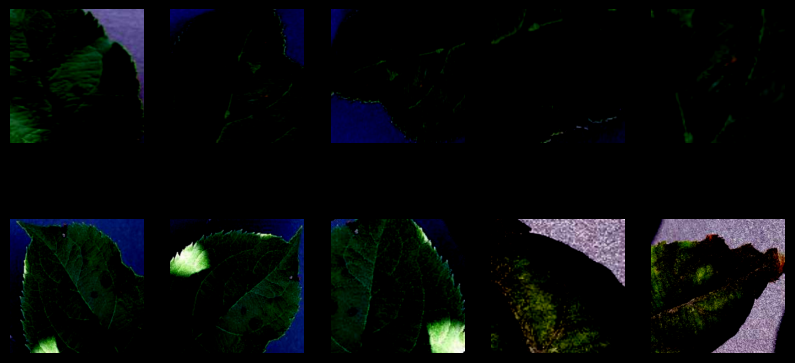

In [21]:
fig,axes = plt.subplots(2,5,figsize=(10,5))
for i,ax in enumerate(axes.flat):
    image,label = train_data[i]
    ax.imshow(image.permute(1,2,0))
    ax.axis('off')
plt.show()

In [22]:
train_loader = DataLoader(train_data, batch_size= 64, shuffle = True, drop_last = True,num_workers = 4,pin_memory=True,persistent_workers = True)
test_loader = DataLoader(test_data, batch_size = 64,num_workers=4,pin_memory=True,persistent_workers = True)

In [23]:
resnet = torchvision.models.resnet18('ResNet18_Weights.DEFAULT')
resnet

C:\Users\amsha\PycharmProjects\PythonProject2\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
summary(resnet.cuda(),(3,256,256))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 128, 128]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 128, 128]        128
├─ReLU: 1-3                              [-1, 64, 128, 128]        --
├─MaxPool2d: 1-4                         [-1, 64, 64, 64]          --
├─Sequential: 1-5                        [-1, 64, 64, 64]          --
|    └─BasicBlock: 2-1                   [-1, 64, 64, 64]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 64, 64]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 64, 64]          128
|    |    └─ReLU: 3-3                    [-1, 64, 64, 64]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 64, 64]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 64, 64]          128
|    |    └─ReLU: 3-6                    [-1, 64, 64, 64]          --
|    └─BasicBlock: 2-2                   [-1, 64, 64, 64]          --
|

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 128, 128]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 128, 128]        128
├─ReLU: 1-3                              [-1, 64, 128, 128]        --
├─MaxPool2d: 1-4                         [-1, 64, 64, 64]          --
├─Sequential: 1-5                        [-1, 64, 64, 64]          --
|    └─BasicBlock: 2-1                   [-1, 64, 64, 64]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 64, 64]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 64, 64]          128
|    |    └─ReLU: 3-3                    [-1, 64, 64, 64]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 64, 64]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 64, 64]          128
|    |    └─ReLU: 3-6                    [-1, 64, 64, 64]          --
|    └─BasicBlock: 2-2                   [-1, 64, 64, 64]          --
|

In [25]:
for p in resnet.parameters():
    p.requires_grad = False

for p in resnet.layer4.parameters():
    p.requires_grad = True

for p in resnet.fc.parameters():
    p.requires_grad = True

In [26]:
resnet.fc = nn.Linear(512,38)
resnet.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
epochs = 10
lossfunc = nn.CrossEntropyLoss()
losses = torch.zeros(epochs)
trainAcc = []
testAcc = []
optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-4)
scaler = GradScaler()
for epoch in range(epochs):
    batchAcc = []
    batchLoss = []
    train_acc = []
    start_time = time.time()
    for X,y in train_loader:
        resnet.train()
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        with autocast():
            ypred = resnet(X)
            loss = lossfunc(ypred, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        batchLoss.append(loss.item())
        acc = 100*(torch.argmax(ypred,dim = 1) == y).float().mean().item()
        train_acc.append(acc)
    end_time = time.time()
    epoch_time = end_time - start_time
    losses[epoch] = np.mean(batchLoss)
    trainAcc.append(np.mean(train_acc))
    all_pred = []
    all_label = []
    with torch.no_grad():
        resnet.eval()
        acc_test = []
        for X,y in test_loader:
            X = X.to(device)
            y = y.to(device)
            ypred = resnet(X)
            preds = torch.argmax(ypred, dim=1)
            all_pred.extend(preds.cpu().numpy())
            all_label.extend(y.cpu().numpy())

            acc = 100*(torch.argmax(ypred,dim = 1) == y).float().mean().item()
            acc_test.append(acc)
        testAcc.append(np.mean(acc_test))

    if epoch % 5 == 0:
        print(f'epoch: {epoch}, loss: {losses[epoch]},time: {epoch_time}')


C:\Users\amsha\AppData\Local\Temp\ipykernel_15624\788228728.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\amsha\AppData\Local\Temp\ipykernel_15624\788228728.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


epoch: 0, loss: 0.41666191816329956,time: 125.31045746803284
epoch: 5, loss: 0.07739581167697906,time: 61.08388638496399


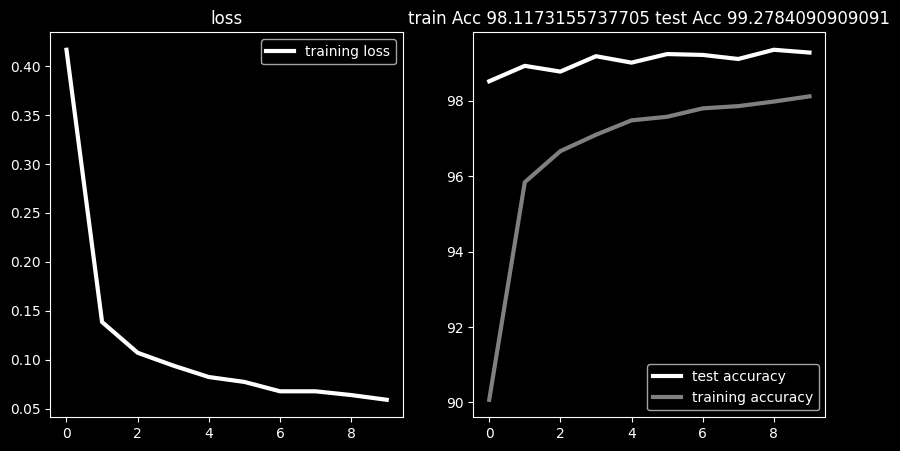

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(losses, 'white', lw=3, label='training loss')
ax[0].set_title('loss')
ax[0].legend()
ax[1].plot(testAcc, 'white', lw=3, label='test accuracy')
ax[1].plot(trainAcc, 'gray', lw=3, label='training accuracy')
ax[1].set_title(f'train Acc {trainAcc[-1]} test Acc {testAcc[-1]}')
ax[1].legend()
plt.show()

<Figure size 2500x2500 with 0 Axes>

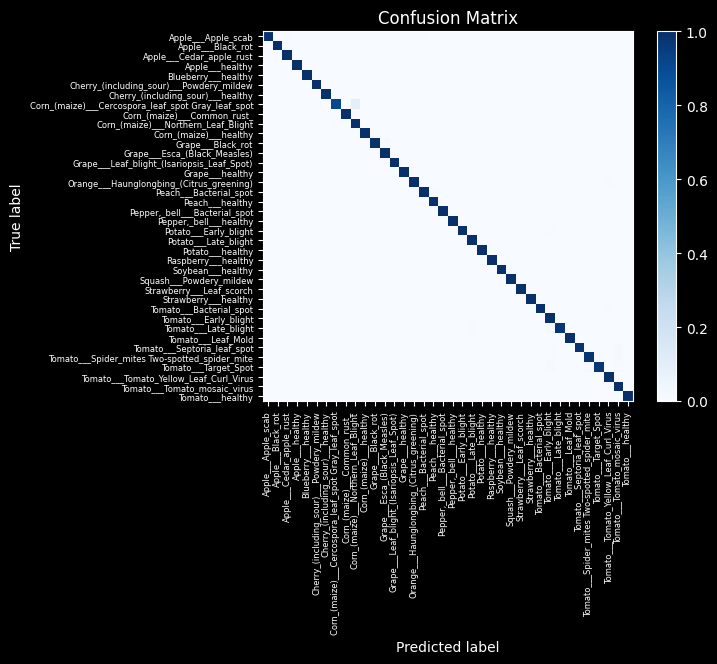

In [35]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(
    all_label,
    all_pred,
    normalize= 'true'
)
plt.figure(figsize = (25,25))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.classes
)
disp.plot(cmap='Blues',xticks_rotation=90,include_values=False)
plt.title('Confusion Matrix')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.show()